# Parte 6 — Interpretabilidade e perguntas de negócio

O desafio não pede só um modelo com boas métricas — pede que a gente
explique **por quê** o modelo decide o que decide, e use isso pra
responder perguntas que um gestor público faria. É isso que fazemos
aqui: Feature Importance, SHAP, e as perguntas de negócio do enunciado.


## 1. Setup e carregar o modelo treinado

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.utils.paths import GOLD_DIR

PASTA_MODELO = GOLD_DIR.parent / "model_input"

pipeline = joblib.load(PASTA_MODELO / "melhor_modelo.joblib")
preprocessor = pipeline.named_steps["preprocessor"]
modelo = pipeline.named_steps["modelo"]

test = pd.read_parquet(PASTA_MODELO / "test.parquet")
print(f"{len(test):,} linhas de teste carregadas")


773,600 linhas de teste carregadas


## 2. Feature Importance nativa da Random Forest

Rápida de calcular (já vem pronta do modelo treinado), mas tem uma
limitação: só diz "o quanto" cada variável importa pro modelo em geral,
não "em que direção" (se aumenta ou diminui a chance de alfabetização).
Isso é o que o SHAP resolve na próxima seção.


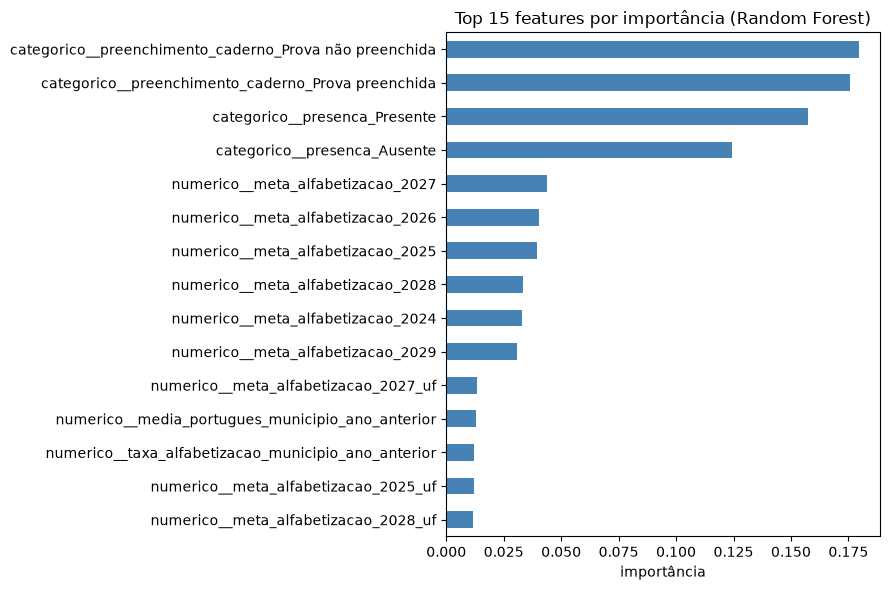

In [2]:
nomes_features = preprocessor.get_feature_names_out()
importancias = pd.Series(modelo.feature_importances_, index=nomes_features)
top_15 = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_15[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 features por importância (Random Forest)")
ax.set_xlabel("importância")
plt.tight_layout()
plt.show()


## 3. SHAP — importância com direção

SHAP nas 3,8 milhões de linhas do teste seria inviável (é uma técnica
cara computacionalmente). Usamos uma **amostra aleatória de 2.000 alunos
do teste** — é o tamanho recomendado na documentação do SHAP pra dar uma
estimativa estável sem explodir o tempo de execução.


In [3]:
from src.preprocessing.pipeline import COLUNAS_CATEGORICAS, COLUNAS_NUMERICAS

amostra_shap = test[COLUNAS_CATEGORICAS + COLUNAS_NUMERICAS].sample(n=2000, random_state=42)
amostra_transformada = preprocessor.transform(amostra_shap)

explainer = shap.TreeExplainer(modelo)
valores_shap = explainer.shap_values(amostra_transformada)

# para classificacao binaria, shap_values pode vir como lista [classe_0, classe_1] ou array 3D -- normalizamos para a classe 1 (alfabetizado)
if isinstance(valores_shap, list):
    valores_shap_classe1 = valores_shap[1]
elif valores_shap.ndim == 3:
    valores_shap_classe1 = valores_shap[:, :, 1]
else:
    valores_shap_classe1 = valores_shap

print("Shape dos valores SHAP:", valores_shap_classe1.shape)


Shape dos valores SHAP: (2000, 75)


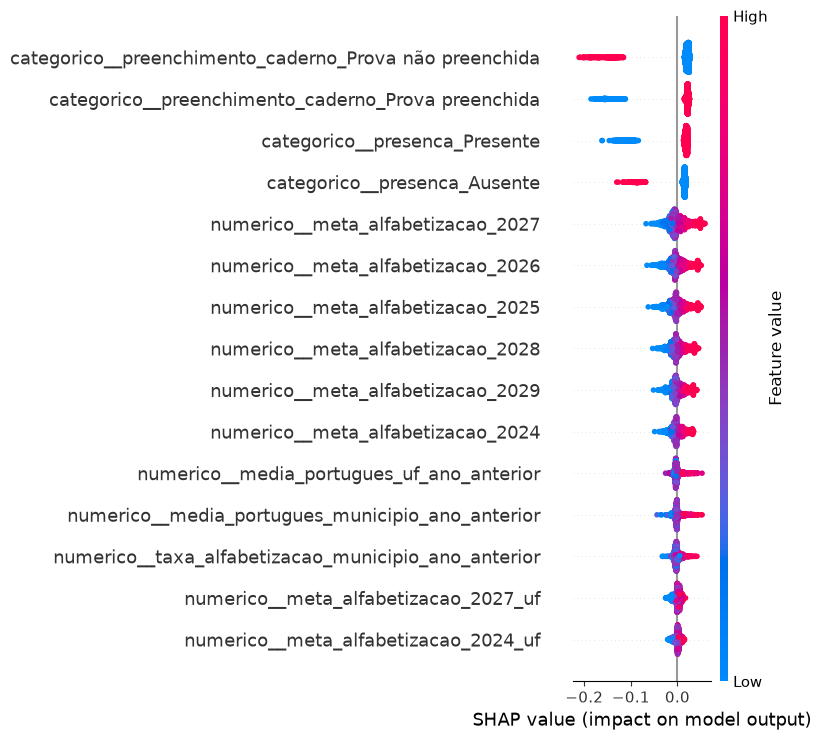

In [4]:
shap.summary_plot(
    valores_shap_classe1,
    amostra_transformada,
    feature_names=nomes_features,
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.show()


**Como ler este gráfico:** cada ponto é um aluno da amostra. A posição
horizontal mostra se aquela variável, pra aquele aluno, empurrou a
previsão pra "alfabetizado" (direita) ou "não alfabetizado" (esquerda).
A cor mostra se o valor da variável era alto (vermelho) ou baixo (azul)
pra aquele aluno. Isso mostra não só quais variáveis importam, mas **em
que direção** — coisa que a Feature Importance da seção 2 não mostra.


## 4. Pergunta de negócio: quais fatores mais impactam a alfabetização?

*(Preencha esta célula com o que apareceu nos seus gráficos — o texto
abaixo é um roteiro do que observar, não a resposta pronta, porque
depende dos nomes exatos que saírem no seu SHAP.)*

Olhando o Feature Importance e o SHAP juntos:
- As variáveis de **contexto territorial** (taxa de alfabetização e
  média de português do município/UF no ano anterior) aparecem entre as
  mais importantes? Isso sustentaria a tese de que o ambiente educacional
  da região pesa tanto quanto características individuais do aluno.
- `rede` (Municipal/Estadual/Privada) tem peso relevante — coerente com
  o que já vimos na EDA (Privada com taxa de alfabetização bem mais alta).
- As metas oficiais (`meta_alfabetizacao_*`) aparecem pouco — faz sentido,
  são metas de governo pra anos futuros, não descrevem o aluno em si.


## 5. Pergunta de negócio: quais municípios têm maior risco educacional?

Usamos a taxa de alfabetização **real observada** por município (não a
previsão do modelo) — é a resposta mais direta e auditável pra essa
pergunta. Filtramos municípios com pelo menos 30 alunos na base, pra não
deixar um município de 2 alunos distorcer o ranking.

**Atenção a um problema de dado que aparece aqui:** alguns municípios têm
100% dos alunos marcados como "Ausente"/"Prova não preenchida" — ou seja,
a prova não foi aplicada (ou não foi registrada) naquele município
naquele ano. Isso não é risco educacional real, é ausência de dado. Por
isso filtramos também pela taxa de presença mínima, não só pela
quantidade de alunos.


In [5]:
base_completa = pd.read_parquet(GOLD_DIR / "base_alunos_modelagem.parquet",
                                  columns=["id_municipio", "sigla_uf", "alfabetizado_flag", "presenca"])

risco_municipio = (
    base_completa.groupby(["id_municipio", "sigla_uf"])
    .agg(
        taxa_alfabetizacao=("alfabetizado_flag", "mean"),
        n_alunos=("alfabetizado_flag", "count"),
        taxa_presenca=("presenca", lambda s: (s == "Presente").mean()),
    )
    .reset_index()
)
risco_municipio = risco_municipio[
    (risco_municipio["n_alunos"] >= 30) & (risco_municipio["taxa_presenca"] >= 0.5)
]

piores_15 = risco_municipio.sort_values("taxa_alfabetizacao").head(15)
piores_15


,id_municipio,sigla_uf,taxa_alfabetizacao,n_alunos,taxa_presenca
2050,2919900,BA,0.078652,89,0.932584
1154,2408706,RN,0.093023,43,0.674419
347,1707702,TO,0.108974,156,0.884615
68,1200435,AC,0.118421,76,0.763158
1169,2410108,RN,0.120773,207,0.753623
1839,2902252,BA,0.122093,172,0.773256
1786,2805109,SE,0.126050,119,0.974790
1870,2904753,BA,0.126183,317,0.889590
317,1703073,TO,0.128834,163,0.907975
1995,2915403,BA,0.140351,171,0.807018


Esses são os municípios com menor taxa de alfabetização observada (com
volume mínimo de alunos pra ser confiável) — candidatos naturais a
priorização de investimento público, na linha do que o enunciado pede.


## 6. Pergunta de negócio: quais regiões têm padrões semelhantes?

Agrupamos por UF (já vimos isso na EDA) e olhamos se estados vizinhos ou
da mesma região do Brasil se agrupam num padrão parecido.


In [6]:
REGIAO_UF = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul",
}

taxa_regiao = base_completa.copy()
taxa_regiao["regiao"] = taxa_regiao["sigla_uf"].map(REGIAO_UF)

resumo_regiao = (
    taxa_regiao.groupby("regiao")["alfabetizado_flag"]
    .agg(taxa_alfabetizacao="mean", n_alunos="count")
    .sort_values("taxa_alfabetizacao")
)
resumo_regiao


,taxa_alfabetizacao,n_alunos
regiao,,
Norte,0.417730,449520
Nordeste,0.506420,1066278
Sul,0.525479,708027
Sudeste,0.535573,1266552
Centro-Oeste,0.546578,377622


Isso complementa o gráfico por UF da EDA (Parte 2) — dá pra ver se a
variação é mais um efeito de região inteira ou se são estados isolados
puxando a média.


## 7. Pergunta de negócio: quais municípios podem não atingir metas futuras?

Reaproveitamos a tabela `metas_vs_resultados`, construída já na Fase 2 —
ela compara a taxa de alfabetização calculada com as metas oficiais até
2030. Calculamos a distância entre a taxa mais recente e a meta de 2030:
quanto maior a distância, mais distante o município está de cumprir a
meta.


In [7]:
metas_vs_resultados = pd.read_parquet(GOLD_DIR / "metas_vs_resultados.parquet")

mais_recente = (
    metas_vs_resultados.sort_values("ano")
    .groupby("id_municipio")
    .tail(1)
    .copy()
)
mais_recente["distancia_da_meta_2030"] = (
    mais_recente["meta_alfabetizacao_2030"] - mais_recente["taxa_alfabetizacao_calculada"]
)

maiores_distancias = mais_recente.sort_values("distancia_da_meta_2030", ascending=False).head(15)
maiores_distancias[["id_municipio", "ano", "taxa_alfabetizacao_calculada", "meta_alfabetizacao_2030", "distancia_da_meta_2030", "total_alunos"]]


,id_municipio,ano,taxa_alfabetizacao_calculada,meta_alfabetizacao_2030,distancia_da_meta_2030,total_alunos
8559,4301750,2024,3.70,80.0,76.30,27
641,1704600,2024,4.76,80.0,75.24,21
715,1712702,2024,8.33,80.0,71.67,24
5877,3162450,2024,8.50,80.0,71.50,247
2417,2414456,2024,8.70,80.0,71.30,46
1427,2203354,2024,10.00,80.0,70.00,50
2287,2408706,2024,10.00,80.0,70.00,20
3655,2902252,2024,10.39,80.0,69.61,77
3549,2805109,2024,10.77,80.0,69.23,65
673,1707702,2024,10.77,80.0,69.23,65


Esses são os municípios com a maior distância entre onde estão hoje e a
meta nacional de 2030 — os que precisariam do salto mais expressivo pra
cumprir o Compromisso Nacional Criança Alfabetizada.
